In [2]:
# Duomenų paruošimas ir bibliotekų importas

import pandas as pd
import numpy as np

cdr_data = pd.read_csv('CDR.csv')
payments_data = pd.read_csv('payments_agg.csv')

In [3]:
# CDR duomenų apžvalga


print(f'Unique call types: {cdr_data["call_type"].unique()}')
print(f'Unique terminate causes: {cdr_data["terminate_cause"].unique()}')


print(' ')
print('--------------------------------Timeframe information----------------------------------')


cdr_data['date'] = pd.to_datetime(cdr_data['date'])
start_date = cdr_data['date'].min()
end_date = cdr_data['date'].max()
total_days = (end_date - start_date).days
years = total_days / 365
print(f"Timeframe of CDR data: days - {total_days}, years - {years}")

# span per account (dienomis)
account_span_days = cdr_data.groupby('account_number')['date'].agg(lambda x: (x.max() - x.min()).days)

# konvertuojam
account_span_months = account_span_days / 30.44
account_span_years = account_span_days / 365.25

# print
print("Timeframe span for unique accounts:")
print(f"Min: {account_span_days.min()} days, {account_span_months.min():.2f} months, {account_span_years.min():.2f} years")
print(f"Max: {account_span_days.max()} days, {account_span_months.max():.2f} months, {account_span_years.max():.2f} years")
print(f"Mean: {account_span_days.mean():.1f} days, {account_span_months.mean():.2f} months, {account_span_years.mean():.2f} years")
print(f"Median: {account_span_days.median()} days, {account_span_months.median():.2f} months, {account_span_years.median():.2f} years")


print(' ')
print('----------------------------Number of distinct account numbers, a_numbers, b_numbers, and destination codes--------------------------------------')


distinct_account_numbers = cdr_data['account_number'].unique()
print(f"Number of distinct account numbers in CDR data: {len(distinct_account_numbers)}")
print(f"Number of calls over all accounts: {len(cdr_data)}")
print(f"Number of unique a_numbers: {cdr_data['a_number'].nunique()}")
print(f"Number of unique b_numbers: {cdr_data['b_number'].nunique()}")
print(f"Number of unique destinations: {cdr_data['destination_code'].nunique()}")


print(' ')
print('-----------------------------------Unique a numbers for accounts-------------------------------')


# 1. kiek unikalių a_number kiekvienam account
a_counts = cdr_data.groupby('account_number')['a_number'].nunique()
# 2. kiek account turi X skirtingų a_number
distribution = a_counts.value_counts().sort_index()
# 3. printinam iki kol reikšmės baigiasi
for i in range(1, distribution.index.max() + 1):
    count = distribution.get(i, 0)
    if count == 0:
        continue
    print(f"Number of accounts with {i} unique a_numbers: {count}")


print(' ')
print('------------------------------Info about a specific account------------------------------------')


acc_number = distinct_account_numbers[56]
id = cdr_data[cdr_data['account_number'] == distinct_account_numbers[56]]

distinct_caller = id['a_number'].unique()
distinct_receiver = id['b_number'].unique()

print(f"Number of distinct callers (a_number) for account {acc_number}: {len(distinct_caller)}")
print(f"Number of distinct receivers (b_number) for account {acc_number}: {len(distinct_receiver)}")
print(f"Number of calls for account {acc_number}: {len(id)}")

id
# cdr_data


Unique call types: ['MINUTES' 'WEBRTC']
Unique terminate causes: ['BUSY' 'ANSWER' 'CANCEL' 'NOANSWER' 'CONGESTION' '0' 'CHANUNAVAIL']
 
--------------------------------Timeframe information----------------------------------
Timeframe of CDR data: days - 728, years - 1.9945205479452055
Timeframe span for unique accounts:
Min: 0 days, 0.00 months, 0.00 years
Max: 728 days, 23.92 months, 1.99 years
Mean: 425.9 days, 13.99 months, 1.17 years
Median: 476.0 days, 15.64 months, 1.30 years
 
----------------------------Number of distinct account numbers, a_numbers, b_numbers, and destination codes--------------------------------------
Number of distinct account numbers in CDR data: 9603
Number of calls over all accounts: 1778973
Number of unique a_numbers: 11685
Number of unique b_numbers: 156238
Number of unique destinations: 2470
 
-----------------------------------Unique a numbers for accounts-------------------------------
Number of accounts with 1 unique a_numbers: 8959
Number of account

,date,a_number,b_number,call_type,destination_code,duration,terminate_cause,account_number
83,2020-08-22 06:30:22,688a52c4af7705abf7031f028222625f,434a31ea74d528691c7b9faf0eff94f5,MINUTES,48886,12.816667,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
205,2020-08-22 07:39:59,688a52c4af7705abf7031f028222625f,434a31ea74d528691c7b9faf0eff94f5,MINUTES,48886,0.700000,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
2476,2020-08-23 07:53:26,688a52c4af7705abf7031f028222625f,434a31ea74d528691c7b9faf0eff94f5,MINUTES,48886,0.350000,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
2478,2020-08-23 07:54:07,688a52c4af7705abf7031f028222625f,434a31ea74d528691c7b9faf0eff94f5,MINUTES,48886,11.366667,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
5935,2020-08-24 12:36:06,688a52c4af7705abf7031f028222625f,434a31ea74d528691c7b9faf0eff94f5,MINUTES,48886,6.033333,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
...,...,...,...,...,...,...,...,...
1715889,2022-07-09 06:14:18,688a52c4af7705abf7031f028222625f,3c257a6832e8c609d88d3215ef0a156b,MINUTES,4850,0.083333,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
1720864,2022-07-12 12:02:10,688a52c4af7705abf7031f028222625f,9af11e51d92566596ca94eff8e3d97ae,MINUTES,48663,43.050000,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
1754456,2022-08-02 14:58:48,688a52c4af7705abf7031f028222625f,3bb68a9c9a26f9f445f565d46190477a,MINUTES,48886,0.083333,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6
1760156,2022-08-06 11:26:35,688a52c4af7705abf7031f028222625f,9af11e51d92566596ca94eff8e3d97ae,MINUTES,48663,29.216667,ANSWER,98e3e0d29dcd16babd3b2fbc6ec2f0e6


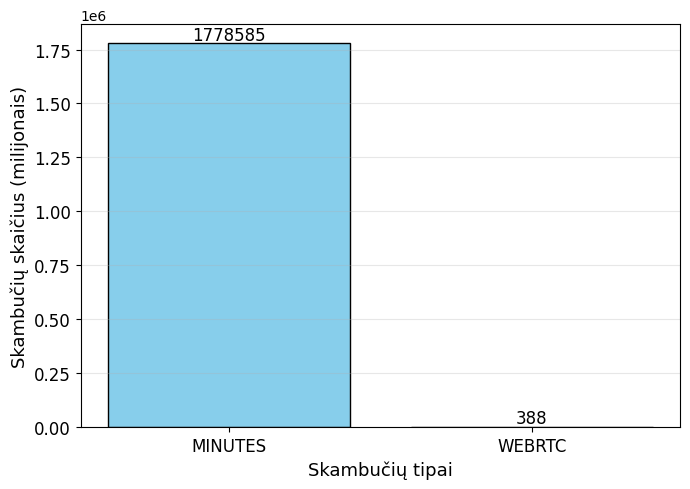

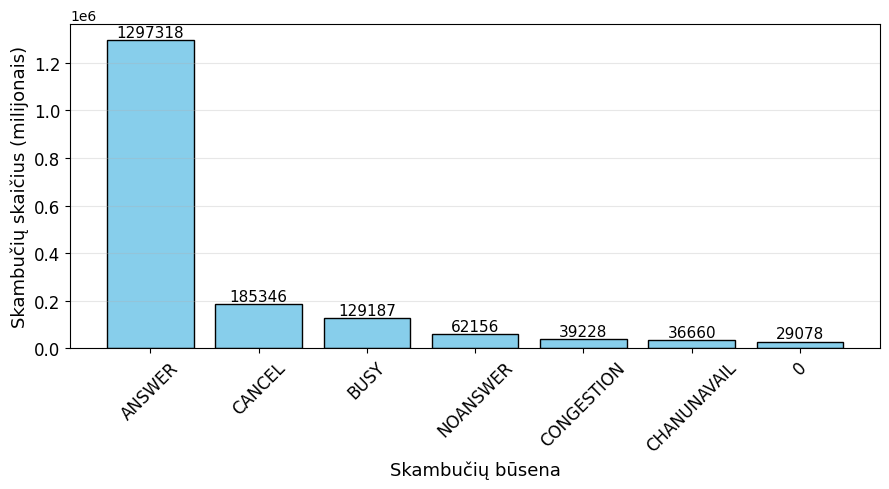

In [4]:
# CDR duomenų pasiskirstymai

import matplotlib.pyplot as plt

# Suskaičiuojam dažnius
call_type_counts = cdr_data['call_type'].value_counts()
terminate_cause_counts = cdr_data['terminate_cause'].value_counts()

# ------------------- 1 grafikas -------------------
plt.figure(figsize=(7,5))

plt.bar(call_type_counts.index,
        call_type_counts.values,
        color=['skyblue', 'skyblue'],
        edgecolor='black')

plt.xlabel('Skambučių tipai', fontsize=13)
plt.ylabel('Skambučių skaičius (milijonais)', fontsize=13)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Skaičiai virš stulpelių
for i, v in enumerate(call_type_counts.values):
    plt.text(i,
             v + max(call_type_counts.values)*0.01,
             str(v),
             ha='center',
             fontsize=12)

plt.tight_layout()
plt.show()


# ------------------- 2 grafikas -------------------
plt.figure(figsize=(9,5))

plt.bar(terminate_cause_counts.index,
        terminate_cause_counts.values,
        color='skyblue',
        edgecolor='black')

plt.xlabel('Skambučių būsena', fontsize=13)
plt.ylabel('Skambučių skaičius (milijonais)', fontsize=13)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Skaičiai virš stulpelių
for i, v in enumerate(terminate_cause_counts.values):
    plt.text(i,
             v + max(terminate_cause_counts.values)*0.01,
             str(v),
             ha='center',
             fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
# Mokėjimų duomenų apžvalga

print(f"Number of unique user_group1 - {payments_data['user_group1'].nunique()}: {payments_data['user_group1'].unique()}")
print(f"Number of unique user_group2 - {payments_data['user_group2'].nunique()}: {payments_data['user_group2'].unique()}")
print(f'Number of rows in payments data: {len(payments_data)}')

# Convert payment dates to datetime
payments_data['first_payment_date'] = pd.to_datetime(payments_data['first_payment_date'])
payments_data['last_payment_date'] = pd.to_datetime(payments_data['last_payment_date'])

# Calculate payment span statistics (temporary, not added to DataFrame)
span_days = (payments_data['last_payment_date'] - payments_data['first_payment_date']).dt.days
span_months = span_days / 30 
span_years = span_days / 365

print(f"\nPayment timeframe span statistics (first to last payment):")
print(f"Min: {span_days.min()} days, {span_months.min():.2f} months, {span_years.min():.2f} years")
print(f"Max: {span_days.max()} days, {span_months.max():.2f} months, {span_years.max():.2f} years") 
print(f"Mean: {span_days.mean():.1f} days, {span_months.mean():.2f} months, {span_years.mean():.2f} years")
print(f"Median: {span_days.median():.0f} days, {span_months.median():.2f} months, {span_years.median():.2f} years")

payments_data

Number of unique user_group1 - 5: ['PLAN_ONLY' 'TOP-UP_ONLY' 'BOTH' 'OTHER' 'ZERO_PAYMENTS_ONLY']
Number of unique user_group2 - 8: ['PLAN_ONLY_SuperCheap' 'PLAN_ONLY_Mixed' 'TOP-UP_ONLY' 'BOTH' 'OTHER'
 'ZERO_PAYMENTS_ONLY' 'PLAN_ONLY_SuperCheap(YEARLY)' 'PLAN_ONLY_Premium']
Number of rows in payments data: 9603

Payment timeframe span statistics (first to last payment):
Min: 0 days, 0.00 months, 0.00 years
Max: 725 days, 24.17 months, 1.99 years
Mean: 326.5 days, 10.88 months, 0.89 years
Median: 350 days, 11.67 months, 0.96 years


,account_number,num_payments,total_amount,avg_amount,max_amount,min_amount,std_amount,num_discounts,last_payment_date,first_payment_date,num_different_products,num_different_plans,user_group1,user_group2
0,0000df940049fa1bbefc699a17671295,10,45.652174,4.565217,4.565217,4.565217,0.000000,0,2021-09-12 11:35:10,2020-09-20 13:39:10,1,1,PLAN_ONLY,PLAN_ONLY_SuperCheap
1,000a38dacb7099ae710216b9cd54087c,8,73.489703,9.186213,43.821510,2.276888,14.017663,1,2021-10-17 19:05:18,2020-12-11 22:33:29,1,2,PLAN_ONLY,PLAN_ONLY_Mixed
2,000b1bddfe23f65af9990f52b3ae004e,2,11.315789,5.657895,6.739130,4.576659,1.529098,1,2022-07-14 14:20:42,2022-07-14 12:22:02,1,1,TOP-UP_ONLY,TOP-UP_ONLY
3,000d7412614cfc8e6d918ca63e1f37dc,8,29.930000,3.741250,4.000000,1.990000,0.707621,1,2021-08-15 21:15:58,2020-11-30 21:18:28,2,2,BOTH,BOTH
4,0013a4303bdffc2658cd40f80227a524,15,66.189931,4.412662,4.565217,2.276888,0.590844,1,2022-06-25 10:02:30,2020-08-27 21:01:23,1,2,PLAN_ONLY,PLAN_ONLY_SuperCheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,14,63.913043,4.565217,4.565217,4.565217,0.000000,0,2022-05-13 12:03:40,2020-10-08 10:08:02,1,2,PLAN_ONLY,PLAN_ONLY_SuperCheap
9599,fff65074634a70efc96bc738e7bf368c,17,77.608696,4.565217,4.565217,4.565217,0.000000,0,2022-04-19 21:13:30,2020-12-25 15:52:26,1,2,PLAN_ONLY,PLAN_ONLY_SuperCheap
9600,fff8217ecefc2d900e361d22d6e90ce0,17,77.643021,4.567237,4.576659,4.565217,0.004496,0,2021-12-14 13:54:15,2020-08-24 11:04:04,2,2,BOTH,BOTH
9601,fff86cfbdc7d0f8b59b65db318798076,6,27.391304,4.565217,4.565217,4.565217,0.000000,0,2021-06-08 17:52:33,2020-09-19 13:03:16,1,1,PLAN_ONLY,PLAN_ONLY_SuperCheap


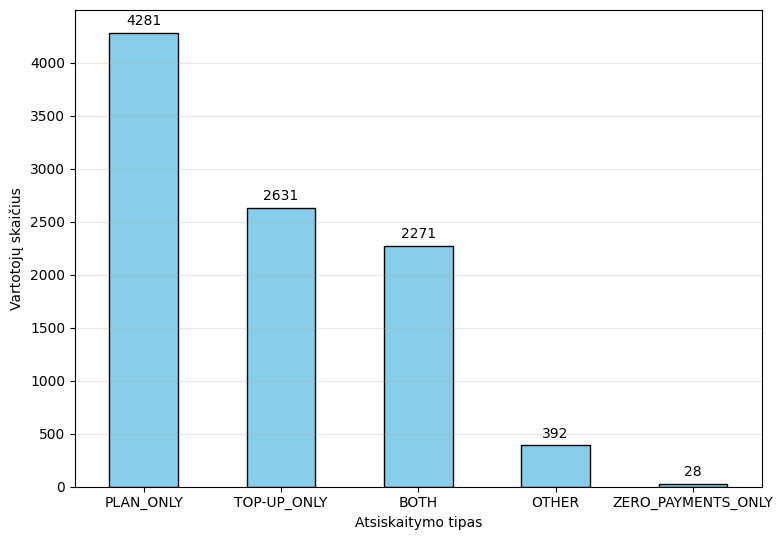

In [6]:
# Vizualizacija user_group1 dažnių
import matplotlib.pyplot as plt

user_group1_freq = payments_data['user_group1'].value_counts()

plt.figure(figsize=(8, 5.5))
user_group1_freq.plot(kind='bar', color='skyblue', edgecolor='black')
# lt.title('Vartotojų atsiskaitymo klasifikacijos dažnių lentelė')
plt.xlabel('Atsiskaitymo tipas')
plt.ylabel('Vartotojų skaičius')
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y', alpha=0.3)

# Pridedame reikšmes ant stulpelių
for i, v in enumerate(user_group1_freq):
    plt.text(i, v + max(user_group1_freq) * 0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [7]:
# --- Požymių konstravimas iš CDR duomenų ---

# =========================
# 1. Laiko požymių formavimas
# =========================
cdr_data['date'] = pd.to_datetime(cdr_data['date'])
cdr_data['call_day'] = cdr_data['date'].dt.date
cdr_data['call_hour'] = cdr_data['date'].dt.hour

# Naktiniai skambučiai: 22:00–05:59, dieniniai skambučiai: 06:00–21:59
cdr_data['is_night_call'] = ((cdr_data['call_hour'] >= 22) | (cdr_data['call_hour'] < 6)).astype(int)
cdr_data['is_day_call'] = ((cdr_data['call_hour'] >= 6) & (cdr_data['call_hour'] < 22)).astype(int)

# =========================
# 2. Pagrindinių agreguotų vartotojo lygmens požymių sudarymas
# =========================
features = cdr_data.groupby('account_number').agg(
    total_calls=('a_number', 'count'),
    total_call_duration=('duration', 'sum'),
    mean_call_duration=('duration', 'mean'),
    max_call_duration=('duration', 'max'),
    
    unique_contacts_called=('b_number', 'nunique'),
    unique_destination_codes=('destination_code', 'nunique'),
    unique_numbers_per_account=('a_number', 'nunique'),
    
    unique_active_days=('call_day', 'nunique'),
    night_calls_count=('is_night_call', 'sum'),
    day_calls_count=('is_day_call', 'sum'),
    
    first_call_date=('date', 'min'),
    last_call_date=('date', 'max')
).reset_index()

# =========================
# 3. Aktyvumo laikotarpio ir intensyvumo požymiai
# =========================
features['days_between_first_and_last_call'] = (
    features['last_call_date'] - features['first_call_date']
).dt.days

# Apsauga nuo dalybos iš nulio, kai pirmas ir paskutinis skambutis sutampa
features['days_between_first_and_last_call'] = features['days_between_first_and_last_call'].replace(0, 1)

# Aktyvių dienų santykis su visu stebėtu laikotarpiu
features['active_day_ratio'] = (
    features['unique_active_days'] / features['days_between_first_and_last_call']
)

# Vidutinis skambučių skaičius per aktyvią dieną
features['avg_calls_per_active_day'] = (
    features['total_calls'] / features['unique_active_days']
)

# =========================
# 4. Pasikartojančio kontakto elgsenos požymiai
# =========================
calls_per_contact = (
    cdr_data.groupby(['account_number', 'b_number'])
    .size()
    .reset_index(name='calls_to_contact')
)

contact_behavior_features = calls_per_contact.groupby('account_number').agg(
    max_calls_to_single_contact=('calls_to_contact', 'max'),
    mean_calls_to_single_contact=('calls_to_contact', 'mean')
).reset_index()

features = features.merge(contact_behavior_features, on='account_number', how='left')

# =========================
# 5. Skambučių baigties požymiai
# =========================
terminate_features = cdr_data.groupby('account_number').agg(
    answered_calls_count=('terminate_cause', lambda x: (x == 'ANSWER').sum()),
    busy_calls_count=('terminate_cause', lambda x: (x == 'BUSY').sum()),
    no_answer_calls_count=('terminate_cause', lambda x: (x == 'NOANSWER').sum()),
    cancelled_calls_count=('terminate_cause', lambda x: (x == 'CANCEL').sum()),
    failed_or_other_calls_count=('terminate_cause', lambda x: x.isin(['CONGESTION', 'CHANUNAVAIL', '0']).sum())
).reset_index()

features = features.merge(terminate_features, on='account_number', how='left')

# Bendras nesėkmingų skambučių skaičius
features['failed_calls_count'] = (
    features['busy_calls_count']
    + features['no_answer_calls_count']
    + features['cancelled_calls_count']
    + features['failed_or_other_calls_count']
)

# Atsilieptų skambučių dalis
features['answered_call_share'] = (
    features['answered_calls_count'] / features['total_calls']
)

# Nesėkmingų skambučių dalis
features['failed_call_share'] = (
    features['failed_calls_count'] / features['total_calls']
)

# =========================
# 6. Laiko struktūros požymiai
# =========================
# Naktinių skambučių dalis bendrame skambučių kiekyje
features['night_call_share'] = (
    features['night_calls_count'] / features['total_calls']
)

# Vidutinis skambučių skaičius vienam vartotojo naudojamam numeriui
features['avg_calls_per_own_number'] = (
    features['total_calls'] / features['unique_numbers_per_account']
)

# =========================
# 7. Skambučių tipo požymiai
# =========================
call_type_features = cdr_data.groupby('account_number').agg(
    minutes_calls_count=('call_type', lambda x: (x == 'MINUTES').sum()),
    webrtc_calls_count=('call_type', lambda x: (x == 'WEBRTC').sum())
).reset_index()

features = features.merge(call_type_features, on='account_number', how='left')

# WEBRTC skambučių dalis bendrame skambučių kiekyje
features['webrtc_call_share'] = (
    features['webrtc_calls_count'] / features['total_calls']
)

# =========================
# 8. Trūkstamų ir begalybės reikšmių sutvarkymas
# =========================
features = features.replace([np.inf, -np.inf], 0).fillna(0)

# =========================
# 9. Galutinės požymių lentelės suformavimas
# =========================
features = features[[
    'account_number',

    'total_calls',
    'total_call_duration',
    'mean_call_duration',
    'max_call_duration',

    'unique_contacts_called',
    'unique_destination_codes',
    'unique_numbers_per_account',

    'unique_active_days',
    'days_between_first_and_last_call',
    'active_day_ratio',
    'avg_calls_per_active_day',
    'avg_calls_per_own_number',

    'night_calls_count',
    'day_calls_count',
    'night_call_share',

    'max_calls_to_single_contact',
    'mean_calls_to_single_contact',

    'answered_calls_count',
    'busy_calls_count',
    'no_answer_calls_count',
    'cancelled_calls_count',
    'failed_or_other_calls_count',
    'failed_calls_count',
    'answered_call_share',
    'failed_call_share',

    'minutes_calls_count',
    'webrtc_calls_count',
    'webrtc_call_share'
]]

features

,account_number,total_calls,total_call_duration,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,...,busy_calls_count,no_answer_calls_count,cancelled_calls_count,failed_or_other_calls_count,failed_calls_count,answered_call_share,failed_call_share,minutes_calls_count,webrtc_calls_count,webrtc_call_share
0,0000df940049fa1bbefc699a17671295,206,1414.000000,6.864078,59.983333,38,23,1,99,411,...,2,1,11,8,22,0.893204,0.106796,206,0,0.0
1,000a38dacb7099ae710216b9cd54087c,121,2792.016667,23.074518,90.016667,9,6,1,85,595,...,4,0,7,9,20,0.834711,0.165289,121,0,0.0
2,000b1bddfe23f65af9990f52b3ae004e,6,26.600000,4.433333,20.900000,4,3,3,2,19,...,0,0,0,1,1,0.833333,0.166667,6,0,0.0
3,000d7412614cfc8e6d918ca63e1f37dc,16,153.100000,9.568750,49.550000,6,4,1,4,197,...,2,0,1,0,3,0.812500,0.187500,16,0,0.0
4,0013a4303bdffc2658cd40f80227a524,1041,4576.433333,4.396190,56.283333,40,14,1,352,695,...,101,15,191,19,326,0.686840,0.313160,1041,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,79,996.116667,12.609072,79.283333,2,1,1,53,590,...,0,6,2,8,16,0.797468,0.202532,79,0,0.0
9599,fff65074634a70efc96bc738e7bf368c,87,826.883333,9.504406,34.916667,16,7,1,61,507,...,0,0,5,6,11,0.873563,0.126437,87,0,0.0
9600,fff8217ecefc2d900e361d22d6e90ce0,721,6889.400000,9.555340,90.016667,46,20,1,248,723,...,75,2,56,11,144,0.800277,0.199723,721,0,0.0
9601,fff86cfbdc7d0f8b59b65db318798076,188,321.816667,1.711791,31.850000,9,9,1,121,349,...,0,0,19,13,32,0.829787,0.170213,188,0,0.0


In [8]:
features.to_excel("Outputs/final_features.xlsx", index=False)

##### POŽYMIŲ RINKINIO PIRMINĖ ANALIZĖ

In [9]:
# Požymių rinkinio analizė
print('Pagrindinės statistinės charakteristikos:\n')
features.describe().T.round(2).applymap(lambda x: f'{x:.2f}'.rstrip('0').rstrip('.'))


Pagrindinės statistinės charakteristikos:



C:\Users\sakal\AppData\Local\Temp\ipykernel_32368\3535052795.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  features.describe().T.round(2).applymap(lambda x: f'{x:.2f}'.rstrip('0').rstrip('.'))


,count,mean,std,min,25%,50%,75%,max
total_calls,9603,185.25,608.81,1,30,84,206,50755
total_call_duration,9603,1305.45,2504.51,0,124.36,479.45,1423.3,52985.08
mean_call_duration,9603,6.98,5.63,0,3.13,5.69,9.35,58.37
max_call_duration,9603,47.06,30.94,0,23.33,42.02,66.31,120
unique_contacts_called,9603,18.8,28.18,1,5,11,22,1002
unique_destination_codes,9603,8.41,8.01,1,3,6,11,168
unique_numbers_per_account,9603,1.24,2.95,1,1,1,1,219
unique_active_days,9603,77.61,99.93,1,14,42,101,716
days_between_first_and_last_call,9603,425.92,256.37,1,179.5,476,681,728
active_day_ratio,9603,0.24,0.3,0,0.07,0.14,0.29,3


In [10]:
# Koreliacijų analizė

print('Koreliacijų analizė:\n')
features_numeric = features.select_dtypes(include=['number'])
features_corr = features_numeric.corr().round(2)
features_corr   


Koreliacijų analizė:



,total_calls,total_call_duration,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,active_day_ratio,...,busy_calls_count,no_answer_calls_count,cancelled_calls_count,failed_or_other_calls_count,failed_calls_count,answered_call_share,failed_call_share,minutes_calls_count,webrtc_calls_count,webrtc_call_share
total_calls,1.00,0.39,0.00,0.15,0.24,0.21,0.03,0.44,0.16,0.17,...,0.87,0.27,0.41,0.39,0.91,0.03,-0.03,1.00,0.01,-0.00
total_call_duration,0.39,1.00,0.33,0.48,0.27,0.25,-0.01,0.78,0.31,0.27,...,0.01,0.35,0.51,0.22,0.09,0.20,-0.20,0.39,-0.01,-0.02
mean_call_duration,0.00,0.33,1.00,0.62,-0.13,-0.15,-0.06,0.12,0.14,-0.02,...,-0.01,-0.00,-0.04,-0.04,-0.02,0.35,-0.35,0.00,-0.01,-0.04
max_call_duration,0.15,0.48,0.62,1.00,0.17,0.21,-0.04,0.40,0.38,-0.05,...,-0.01,0.16,0.23,0.09,0.03,0.24,-0.24,0.15,-0.02,-0.04
unique_contacts_called,0.24,0.27,-0.13,0.17,1.00,0.85,0.10,0.39,0.29,0.06,...,0.01,0.24,0.42,0.24,0.07,0.03,-0.03,0.24,-0.00,-0.01
unique_destination_codes,0.21,0.25,-0.15,0.21,0.85,1.00,0.05,0.39,0.34,0.01,...,0.01,0.19,0.37,0.21,0.06,0.05,-0.05,0.21,-0.00,-0.02
unique_numbers_per_account,0.03,-0.01,-0.06,-0.04,0.10,0.05,1.00,0.00,-0.02,0.01,...,0.01,-0.00,0.00,0.03,0.01,0.02,-0.02,0.03,0.01,0.01
unique_active_days,0.44,0.78,0.12,0.40,0.39,0.39,0.00,1.00,0.48,0.29,...,0.04,0.38,0.59,0.29,0.12,0.23,-0.23,0.44,-0.00,-0.02
days_between_first_and_last_call,0.16,0.31,0.14,0.38,0.29,0.34,-0.02,0.48,1.00,-0.34,...,0.00,0.17,0.25,0.13,0.04,0.16,-0.16,0.16,-0.00,-0.04
active_day_ratio,0.17,0.27,-0.02,-0.05,0.06,0.01,0.01,0.29,-0.34,1.00,...,0.03,0.12,0.19,0.09,0.05,0.01,-0.01,0.17,-0.00,0.02


In [11]:
features_corr.to_excel("Outputs/features_corr.xlsx", index=True)

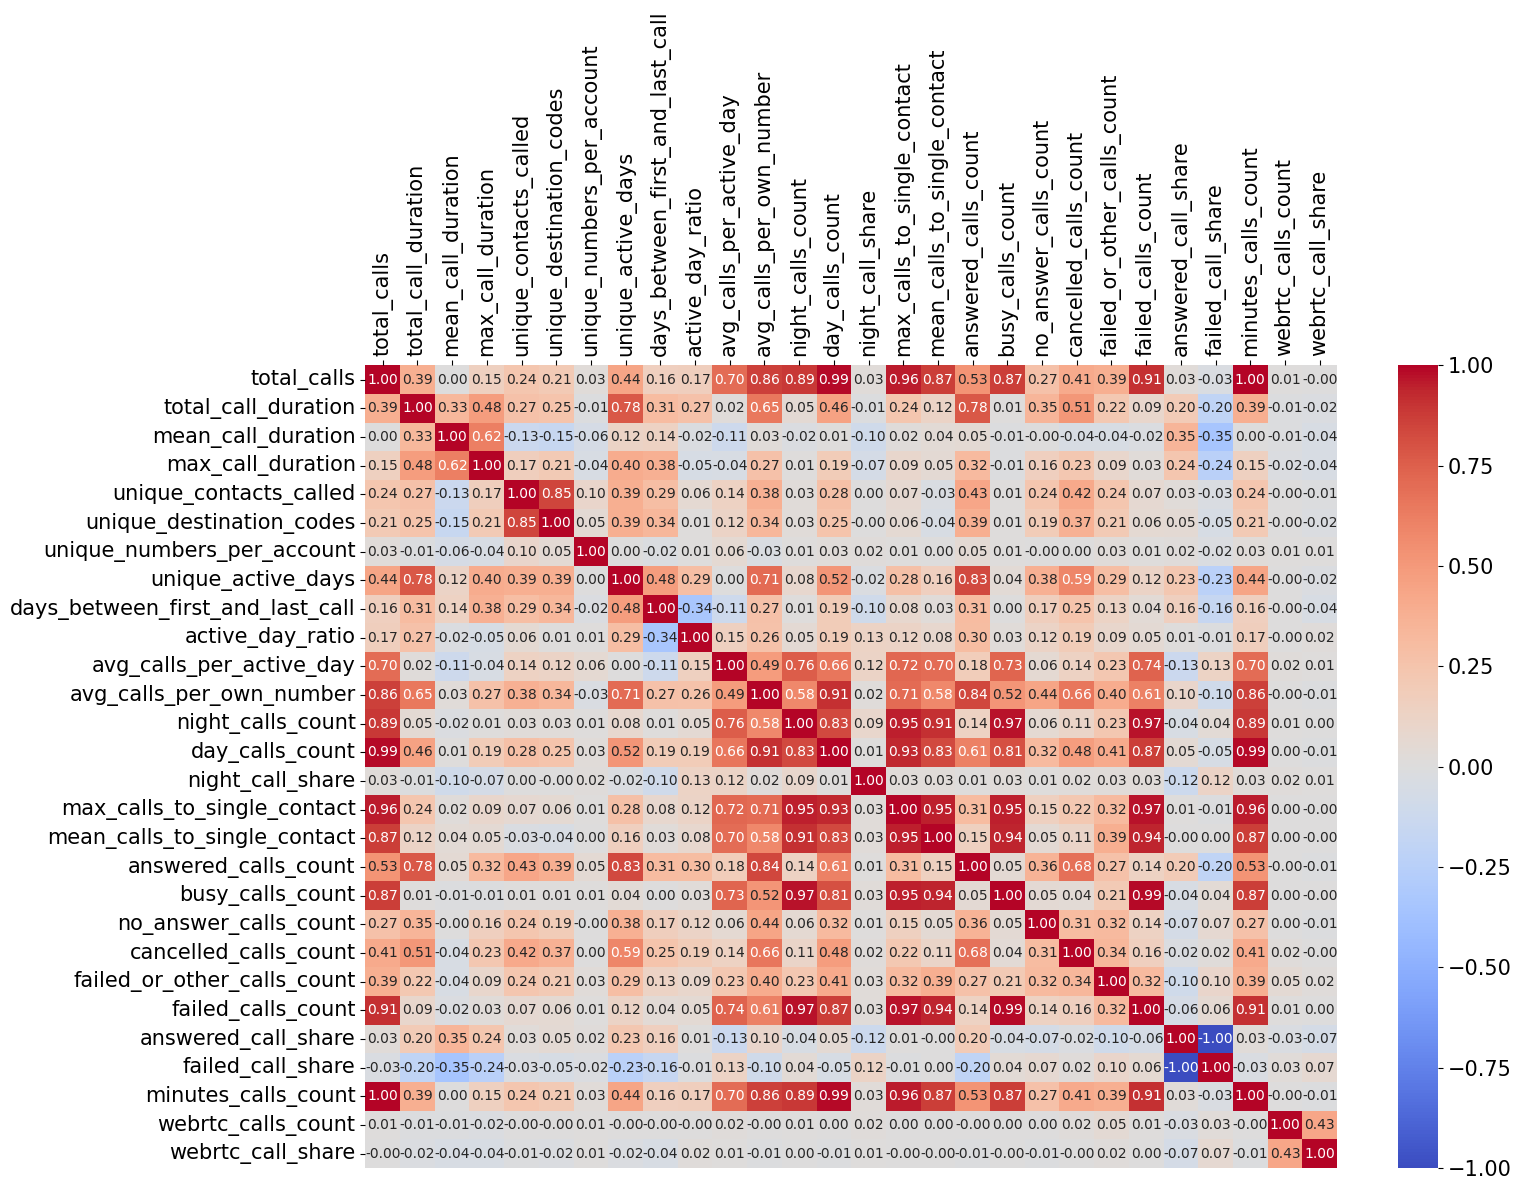

In [12]:
# Koreliacijų vizualizacija
import seaborn as sns

plt.figure(figsize=(16, 12))

ax = sns.heatmap(
    features_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    # square=True
)

# Pavadinimai viršuje
ax.xaxis.tick_top()

# Teksto pasukimas
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Šriftų dydžiai
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

# Colorbar skaičių dydis
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()

plt.show()

In [13]:
# Koreliuojančių požymių pašalinimas

features_droped = features.drop(columns=['total_calls', 'total_call_duration', 'failed_call_share', 'answered_call_share', 'night_call_share', 'webrtc_call_share', 'failed_or_other_calls_count', 'failed_calls_count', 'minutes_calls_count'])
features_droped

,account_number,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,active_day_ratio,avg_calls_per_active_day,avg_calls_per_own_number,night_calls_count,day_calls_count,max_calls_to_single_contact,mean_calls_to_single_contact,answered_calls_count,busy_calls_count,no_answer_calls_count,cancelled_calls_count,webrtc_calls_count
0,0000df940049fa1bbefc699a17671295,6.864078,59.983333,38,23,1,99,411,0.240876,2.080808,206.0,0,206,115,5.421053,184,2,1,11,0
1,000a38dacb7099ae710216b9cd54087c,23.074518,90.016667,9,6,1,85,595,0.142857,1.423529,121.0,0,121,72,13.444444,101,4,0,7,0
2,000b1bddfe23f65af9990f52b3ae004e,4.433333,20.900000,4,3,3,2,19,0.105263,3.000000,2.0,0,6,2,1.500000,5,0,0,0,0
3,000d7412614cfc8e6d918ca63e1f37dc,9.568750,49.550000,6,4,1,4,197,0.020305,4.000000,16.0,0,16,5,2.666667,13,2,0,1,0
4,0013a4303bdffc2658cd40f80227a524,4.396190,56.283333,40,14,1,352,695,0.506475,2.957386,1041.0,134,907,738,26.025000,715,101,15,191,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,12.609072,79.283333,2,1,1,53,590,0.089831,1.490566,79.0,0,79,66,39.500000,63,0,6,2,0
9599,fff65074634a70efc96bc738e7bf368c,9.504406,34.916667,16,7,1,61,507,0.120316,1.426230,87.0,0,87,37,5.437500,76,0,0,5,0
9600,fff8217ecefc2d900e361d22d6e90ce0,9.555340,90.016667,46,20,1,248,723,0.343015,2.907258,721.0,16,705,538,15.673913,577,75,2,56,0
9601,fff86cfbdc7d0f8b59b65db318798076,1.711791,31.850000,9,9,1,121,349,0.346705,1.553719,188.0,1,187,138,20.888889,156,0,0,19,0


### Normalizavimas

In [ ]:
# Požymių normalizavimas naudojant RobustScaler

from sklearn.preprocessing import RobustScaler

# Pasirenkame tik skaitinius požymius normalizavimui
features_numeric = features_droped.select_dtypes(include=['number'])

# Pritaikome RobustScaler normalizavimui
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features_numeric)

scaled_features = pd.DataFrame(
    features_scaled,
    columns=features_numeric.columns,
    index=features_droped.index
)

# Peržiūrime normalizuotų požymių pagrindines statistines charakteristikas
scaled_features.describe().T.round(2).applymap(lambda x: f'{x:.2f}'.rstrip('0').rstrip('.'))


C:\Users\sakal\AppData\Local\Temp\ipykernel_32368\1938261423.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  scaled_features.describe().T.round(2).applymap(lambda x: f'{x:.2f}'.rstrip('0').rstrip('.'))


,count,mean,std,min,25%,50%,75%,max
mean_call_duration,9603,0.21,0.9,-0.91,-0.41,0,0.59,8.47
max_call_duration,9603,0.12,0.72,-0.98,-0.43,0,0.57,1.81
unique_contacts_called,9603,0.46,1.66,-0.59,-0.35,0,0.65,58.29
unique_destination_codes,9603,0.3,1,-0.62,-0.38,0,0.62,20.25
unique_numbers_per_account,9603,0.24,2.95,0,0,0,0,218
unique_active_days,9603,0.41,1.15,-0.47,-0.32,0,0.68,7.75
days_between_first_and_last_call,9603,-0.1,0.51,-0.95,-0.59,0,0.41,0.5
active_day_ratio,9603,0.48,1.37,-0.62,-0.33,0,0.67,13.1
avg_calls_per_active_day,9603,0.45,3.98,-1.07,-0.4,0,0.6,282.64
avg_calls_per_own_number,9603,0.56,2.08,-0.46,-0.31,0,0.69,100.23


In [15]:
# Patikriname, ar indeksai sutampa tarp features_droped ir scaled_features
features_droped.index.equals(scaled_features.index)

True

In [16]:
# Įterpiame 'account_number' atgal į normalizuotų požymių DataFrame
scaled_features.insert(0, 'account_number', features['account_number'])
scaled_features

,account_number,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,active_day_ratio,avg_calls_per_active_day,avg_calls_per_own_number,night_calls_count,day_calls_count,max_calls_to_single_contact,mean_calls_to_single_contact,answered_calls_count,busy_calls_count,no_answer_calls_count,cancelled_calls_count,webrtc_calls_count
0,0000df940049fa1bbefc699a17671295,0.189056,0.418073,1.588235,2.125,0.0,0.655172,-0.129611,0.463529,0.130939,0.755952,0.000000,0.723032,1.106667,-0.097895,0.939850,0.000,0.000000,0.157895,0.0
1,000a38dacb7099ae710216b9cd54087c,2.795097,1.116928,-0.117647,0.000,0.0,0.494253,0.237288,0.014483,-0.599371,0.250000,0.000000,0.227405,0.533333,0.704444,0.315789,0.250,-0.181818,-0.052632,0.0
2,000b1bddfe23f65af9990f52b3ae004e,-0.201718,-0.491371,-0.411765,-0.375,2.0,-0.459770,-0.911266,-0.157743,1.152263,-0.458333,0.000000,-0.443149,-0.400000,-0.490000,-0.406015,-0.250,-0.181818,-0.421053,0.0
3,000d7412614cfc8e6d918ca63e1f37dc,0.623868,0.175296,-0.294118,-0.250,0.0,-0.436782,-0.556331,-0.546958,2.263374,-0.375000,0.000000,-0.384840,-0.360000,-0.373333,-0.345865,0.000,-0.181818,-0.368421,0.0
4,0013a4303bdffc2658cd40f80227a524,-0.207689,0.331976,1.705882,1.000,0.0,3.563218,0.436690,1.680298,1.104915,5.726190,44.666667,4.810496,9.413333,1.962500,4.932331,12.375,2.545455,9.631579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,1.112639,0.867171,-0.529412,-0.625,0.0,0.126437,0.227318,-0.228444,-0.524885,0.000000,0.000000,-0.017493,0.453333,3.310000,0.030075,-0.250,0.909091,-0.315789,0.0
9599,fff65074634a70efc96bc738e7bf368c,0.613524,-0.165212,0.294118,0.125,0.0,0.218391,0.061815,-0.088785,-0.596371,0.047619,0.000000,0.029155,0.066667,-0.096250,0.127820,-0.250,-0.181818,-0.157895,0.0
9600,fff8217ecefc2d900e361d22d6e90ce0,0.621712,1.116928,2.058824,1.750,0.0,2.367816,0.492522,0.931453,1.049217,3.821429,5.333333,3.632653,6.746667,0.927391,3.894737,9.125,0.181818,2.526316,0.0
9601,fff86cfbdc7d0f8b59b65db318798076,-0.639242,-0.236572,-0.117647,0.375,0.0,0.908046,-0.253240,0.948356,-0.454716,0.648810,0.333333,0.612245,1.413333,1.448889,0.729323,-0.250,-0.181818,0.578947,0.0


In [17]:
scaled_features.to_excel("Outputs/scaled_features.xlsx", index=False)